# TT-13 — LASSO REGRESSION (L1)
## Chọn ra 10 chỉ số xét nghiệm quan trọng nhất trong 200 chỉ số

**Bài toán:** Bệnh viện muốn xây bộ xét nghiệm sàng lọc tiến triển bệnh tiểu đường
từ 200 chỉ số sinh hoá, nhưng chỉ muốn giữ lại ~10 chỉ số đủ tốt để dự đoán,
nhằm giảm chi phí xét nghiệm cho bệnh nhân.



## 0. Import thư viện

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV, lasso_path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True


Matplotlib is building the font cache; this may take a moment.


## Bước 1 — Nạp `load_diabetes`, mở rộng thành 200 cột (10 thật + 190 nhiễu)



In [5]:
X, y = load_diabetes(return_X_y=True, as_frame=True)

BIEN_THAT = list(X.columns)          # 10 tên cột thật (age, sex, bmi, bp, s1..s6)
print("10 biến THẬT:", BIEN_THAT)

# Thêm 190 cột NHIỄU thuần tuý
rng = np.random.default_rng(RANDOM_STATE)
nhieu = pd.DataFrame(
    rng.normal(size=(len(X), 190)),
    columns=[f'chi_so_nhieu_{i:03d}' for i in range(190)]
)

X_full = pd.concat([X, nhieu], axis=1)      # 200 cột, chỉ 10 cột có tín hiệu thật
BIEN_NHIEU = list(nhieu.columns)

print(f"Kích thước X_full: {X_full.shape}  (kỳ vọng: (442, 200))")
X_full.head()


10 biến THẬT: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Kích thước X_full: (442, 200)  (kỳ vọng: (442, 200))


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,...,chi_so_nhieu_180,chi_so_nhieu_181,chi_so_nhieu_182,chi_so_nhieu_183,chi_so_nhieu_184,chi_so_nhieu_185,chi_so_nhieu_186,chi_so_nhieu_187,chi_so_nhieu_188,chi_so_nhieu_189
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,...,1.306002,0.219383,-0.410927,1.106289,0.428756,1.535756,0.183234,-1.224469,-1.368159,1.650928
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,...,0.011426,1.328961,0.856794,0.841820,0.554117,2.327653,-0.205162,-2.003522,1.604254,-0.457699
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,...,-0.070680,0.334295,0.051142,-0.765535,0.900185,0.739413,-0.159648,-0.652916,0.548428,0.187974
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,...,0.011451,-0.299265,-1.015068,2.048756,1.785168,1.136049,-0.920850,0.855019,0.639626,0.442546
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,...,0.211610,0.886394,0.490767,1.200306,0.289359,-0.355698,0.335841,-2.930594,0.382886,-3.648413


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (353, 200) | Test: (89, 200)


## Bước 2 — Baseline: Linear Regression trên 200 cột → quan sát overfit nặng



In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, lr.predict(X_train)))
rmse_test_lr  = np.sqrt(mean_squared_error(y_test, lr.predict(X_test)))

print(f"Linear Regression (baseline, 200 biến):")
print(f"  RMSE train = {rmse_train_lr:.3f}")
print(f"  RMSE test  = {rmse_test_lr:.3f}")
print(f"  Số hệ số != 0: {(lr.coef_ != 0).sum()}/200  (Linear Regression không loại biến nào)")
print(f"  → Chênh lệch train/test càng lớn thì overfit càng nặng.")


Linear Regression (baseline, 200 biến):
  RMSE train = 33.989
  RMSE test  = 84.780
  Số hệ số != 0: 200/200  (Linear Regression không loại biến nào)
  → Chênh lệch train/test càng lớn thì overfit càng nặng.


## Bước 3 — LassoCV dò alpha



In [8]:
pipe = Pipeline([
    ('scale', StandardScaler()),             
    ('lasso', LassoCV(alphas=np.logspace(-4, 1, 100), cv=5,
                      max_iter=50000, random_state=RANDOM_STATE)),
])
pipe.fit(X_train, y_train)

alpha_toi_uu = pipe['lasso'].alpha_
he_so = pipe['lasso'].coef_
so_bien_giu = (he_so != 0).sum()

print(f"Alpha tối ưu (theo CV): {alpha_toi_uu:.5f}")
print(f"Lasso giữ lại {so_bien_giu}/200 biến")

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, pipe.predict(X_train)))
rmse_test_lasso  = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))
print(f"RMSE train = {rmse_train_lasso:.3f} | RMSE test = {rmse_test_lasso:.3f}")


Alpha tối ưu (theo CV): 7.92483
Lasso giữ lại 5/200 biến
RMSE train = 56.282 | RMSE test = 53.728


## Bước 4 — Chấm điểm chọn biến

- **Recall chọn biến**: trong 10 biến THẬT, Lasso giữ lại bao nhiêu?
- **False positive**: trong số biến nhiễu, bao nhiêu bị giữ nhầm?

In [9]:
bien_duoc_giu = X_full.columns[he_so != 0].tolist()

that_duoc_giu   = [b for b in bien_duoc_giu if b in BIEN_THAT]
nhieu_bi_giu_nham = [b for b in bien_duoc_giu if b in BIEN_NHIEU]

bang_cham_diem = pd.DataFrame({
    'Chỉ số': [
        'Số biến THẬT được giữ (recall)',
        'Số biến NHIỄU bị giữ nhầm (false positive)',
        'Tổng số biến Lasso giữ lại',
        'Alpha tối ưu',
    ],
    'Giá trị': [
        f"{len(that_duoc_giu)}/10",
        f"{len(nhieu_bi_giu_nham)}/190",
        f"{so_bien_giu}/200",
        f"{alpha_toi_uu:.5f}",
    ]
})

print("BẢNG CHẤM ĐIỂM CHỌN BIẾN")
display(bang_cham_diem)

print("\nCác biến THẬT được giữ:   ", that_duoc_giu)
print("Các biến THẬT bị loại:    ", [b for b in BIEN_THAT if b not in that_duoc_giu])
print("Vài biến NHIỄU bị giữ nhầm (nếu có):", nhieu_bi_giu_nham[:10])


BẢNG CHẤM ĐIỂM CHỌN BIẾN


,Chỉ số,Giá trị
0,Số biến THẬT được giữ (recall),4/10
1,Số biến NHIỄU bị giữ nhầm (false positive),1/190
2,Tổng số biến Lasso giữ lại,5/200
3,Alpha tối ưu,7.92483



Các biến THẬT được giữ:    ['bmi', 'bp', 's3', 's5']
Các biến THẬT bị loại:     ['age', 'sex', 's1', 's2', 's4', 's6']
Vài biến NHIỄU bị giữ nhầm (nếu có): ['chi_so_nhieu_009']


## Bước 5 — Vẽ coefficient path của Lasso

Coefficient path cho thấy khi alpha (độ phạt) tăng dần, các hệ số lần lượt
"rơi" về đúng 0 — trực quan hoá đúng cơ chế chọn biến của Lasso.

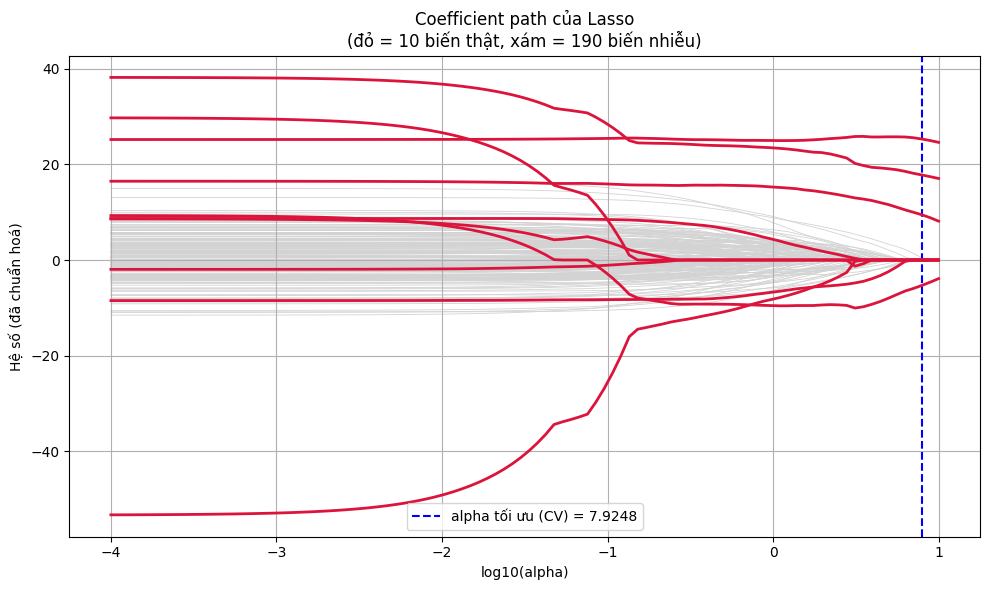

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    alphas=np.logspace(-4, 1, 100),
    max_iter=50000,
)

fig, ax = plt.subplots(figsize=(10, 6))
for i, ten_bien in enumerate(X_full.columns):
    mau = 'crimson' if ten_bien in BIEN_THAT else 'lightgray'
    do_day = 2 if ten_bien in BIEN_THAT else 0.6
    zorder = 3 if ten_bien in BIEN_THAT else 1
    ax.plot(np.log10(alphas_path), coefs_path[i], color=mau, linewidth=do_day, zorder=zorder)

ax.axvline(np.log10(alpha_toi_uu), color='blue', linestyle='--', label=f'alpha tối ưu (CV) = {alpha_toi_uu:.4f}')
ax.set_xlabel('log10(alpha)')
ax.set_ylabel('Hệ số (đã chuẩn hoá)')
ax.set_title('Coefficient path của Lasso\n(đỏ = 10 biến thật, xám = 190 biến nhiễu)')
ax.legend()
plt.tight_layout()
plt.savefig('lasso_path.png', dpi=120)
plt.show()


## Bước 6 — Vẽ RMSE train/test theo alpha

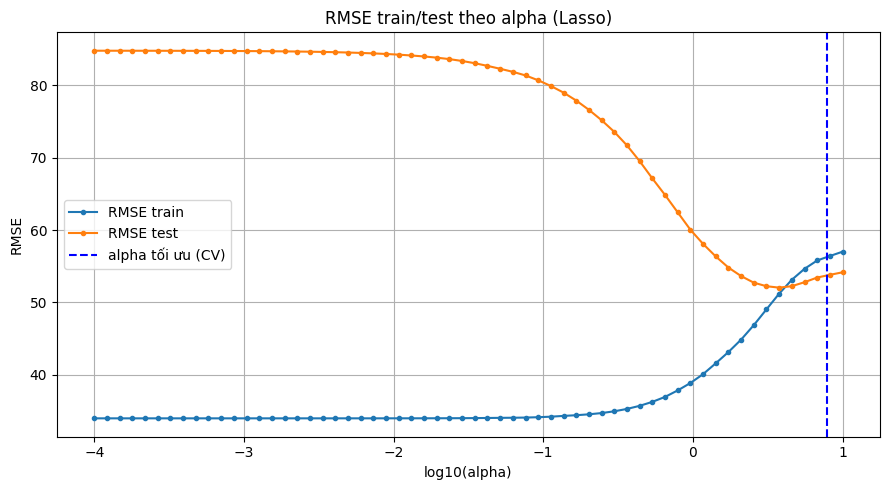

In [11]:
alphas_ve = np.logspace(-4, 1, 60)
rmse_train_list, rmse_test_list = [], []

for a in alphas_ve:
    mo_hinh = Pipeline([
        ('scale', StandardScaler()),
        ('lasso', Lasso(alpha=a, max_iter=50000, random_state=RANDOM_STATE)),
    ])
    mo_hinh.fit(X_train, y_train)
    rmse_train_list.append(np.sqrt(mean_squared_error(y_train, mo_hinh.predict(X_train))))
    rmse_test_list.append(np.sqrt(mean_squared_error(y_test, mo_hinh.predict(X_test))))

fig, ax = plt.subplots()
ax.plot(np.log10(alphas_ve), rmse_train_list, label='RMSE train', marker='o', markersize=3)
ax.plot(np.log10(alphas_ve), rmse_test_list, label='RMSE test', marker='o', markersize=3)
ax.axvline(np.log10(alpha_toi_uu), color='blue', linestyle='--', label='alpha tối ưu (CV)')
ax.set_xlabel('log10(alpha)')
ax.set_ylabel('RMSE')
ax.set_title('RMSE train/test theo alpha (Lasso)')
ax.legend()
plt.tight_layout()
plt.show()


## Bước 7 — So sánh Ridge vs Lasso trên cùng dữ liệu



In [12]:
pipe_ridge = Pipeline([
    ('scale', StandardScaler()),
    ('ridge', RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5)),
])
pipe_ridge.fit(X_train, y_train)

he_so_ridge = pipe_ridge['ridge'].coef_
so_bien_giu_ridge = (he_so_ridge != 0).sum()  

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, pipe_ridge.predict(X_train)))
rmse_test_ridge  = np.sqrt(mean_squared_error(y_test, pipe_ridge.predict(X_test)))

bang_so_sanh = pd.DataFrame({
    'Mô hình': ['Linear Regression (baseline)', 'Ridge (L2)', 'Lasso (L1)'],
    'Số biến giữ lại': [(lr.coef_ != 0).sum(), so_bien_giu_ridge, so_bien_giu],
    'RMSE train': [rmse_train_lr, rmse_train_ridge, rmse_train_lasso],
    'RMSE test':  [rmse_test_lr,  rmse_test_ridge,  rmse_test_lasso],
})

print("BẢNG SO SÁNH RIDGE vs LASSO vs LINEAR REGRESSION")
display(bang_so_sanh)


BẢNG SO SÁNH RIDGE vs LASSO vs LINEAR REGRESSION


,Mô hình,Số biến giữ lại,RMSE train,RMSE test
0,Linear Regression (baseline),200,33.989397,84.779750
1,Ridge (L2),200,46.770772,58.047273
2,Lasso (L1),5,56.282169,53.728013


## Bước 8 — Thí nghiệm biến tương quan

Nhân đôi 1 cột thật  và thêm nhiễu nhỏ để tạo ra 2 biến tương quan
rất cao. Lasso sẽ chỉ giữ 1 trong 2 biến gần như ngẫu nhiên.

In [13]:
bien_can_nhan_ban = 'bmi'

def tao_du_lieu_trung_lap(X_goc, seed):
    rng_local = np.random.default_rng(seed)
    X_moi = X_goc.copy()
    nhieu_nho = rng_local.normal(scale=0.01 * X_goc[bien_can_nhan_ban].std(), size=len(X_goc))
    X_moi[f'{bien_can_nhan_ban}_ban_sao'] = X_goc[bien_can_nhan_ban] + nhieu_nho
    return X_moi

ket_qua_thi_nghiem = []
for seed in [1, 2, 3, 42, 100]:
    X_full_dup = tao_du_lieu_trung_lap(X_full, seed)
    X_tr, X_te, y_tr, y_te = train_test_split(X_full_dup, y, test_size=0.2, random_state=RANDOM_STATE)

    # Lưới alpha nhẹ hơn Bước 3 (chỉ để minh hoạ tính KHÔNG ổn định, không cần
    # dò alpha thật mịn) — giúp thí nghiệm 5 lần chạy nhanh hơn nhiều.
    pipe_dup = Pipeline([
        ('scale', StandardScaler()),
        ('lasso', LassoCV(alphas=np.logspace(-3, 1, 30), cv=3,
                          max_iter=20000, random_state=RANDOM_STATE)),
    ])
    pipe_dup.fit(X_tr, y_tr)

    he_so_dup = pd.Series(pipe_dup['lasso'].coef_, index=X_full_dup.columns)
    goc = he_so_dup[bien_can_nhan_ban]
    ban_sao = he_so_dup[f'{bien_can_nhan_ban}_ban_sao']

    ket_qua_thi_nghiem.append({
        'seed_tao_nhieu': seed,
        f'he_so_{bien_can_nhan_ban}_goc': round(goc, 4),
        f'he_so_{bien_can_nhan_ban}_ban_sao': round(ban_sao, 4),
        'bien_duoc_chon': bien_can_nhan_ban if abs(goc) > abs(ban_sao) else f'{bien_can_nhan_ban}_ban_sao'
                          if (goc != 0 or ban_sao != 0) else 'không biến nào'
    })

bang_thi_nghiem = pd.DataFrame(ket_qua_thi_nghiem)
print("KẾT QUẢ THÍ NGHIỆM BIẾN TƯƠNG QUAN (chạy lại với 5 seed khác nhau)")
display(bang_thi_nghiem)
print("\n→ Nhận xét: nếu cột 'bien_duoc_chon' đổi qua các seed, chứng tỏ lựa chọn")
print("  của Lasso KHÔNG ổn định khi có biến tương quan cao — đúng như README cảnh báo.")


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.805e+03, tolerance: 1.418e+02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.847e+04, tolerance: 1.418e+02
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, che

KẾT QUẢ THÍ NGHIỆM BIẾN TƯƠNG QUAN (chạy lại với 5 seed khác nhau)


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.867e+04, tolerance: 1.428e+02
  model = cd_fast.enet_coordinate_descent_gram(


,seed_tao_nhieu,he_so_bmi_goc,he_so_bmi_ban_sao,bien_duoc_chon
0,1,25.1360,0.3423,bmi
1,2,0.0000,25.4932,bmi_ban_sao
2,3,25.4772,0.0000,bmi
3,42,0.0000,25.5084,bmi_ban_sao
4,100,0.0000,25.5811,bmi_ban_sao



→ Nhận xét: nếu cột 'bien_duoc_chon' đổi qua các seed, chứng tỏ lựa chọn
  của Lasso KHÔNG ổn định khi có biến tương quan cao — đúng như README cảnh báo.


## Bước 9 — Train lại Linear Regression CHỈ trên các biến Lasso chọn (debiased lasso)



In [14]:
bien_lasso_chon = X_full.columns[he_so != 0].tolist()
print(f"Số biến được Lasso chọn: {len(bien_lasso_chon)}")

lr_debiased = LinearRegression()
lr_debiased.fit(X_train[bien_lasso_chon], y_train)

rmse_train_debiased = np.sqrt(mean_squared_error(y_train, lr_debiased.predict(X_train[bien_lasso_chon])))
rmse_test_debiased  = np.sqrt(mean_squared_error(y_test, lr_debiased.predict(X_test[bien_lasso_chon])))

bang_debiased = pd.DataFrame({
    'Mô hình': ['Lasso đầy đủ (200 biến, hệ số bị co)', 'Debiased Lasso (chỉ biến được chọn, không phạt)'],
    'Số biến': [200, len(bien_lasso_chon)],
    'RMSE train': [rmse_train_lasso, rmse_train_debiased],
    'RMSE test':  [rmse_test_lasso,  rmse_test_debiased],
})
print("SO SÁNH LASSO ĐẦY ĐỦ vs DEBIASED LASSO")
display(bang_debiased)


Số biến được Lasso chọn: 5
SO SÁNH LASSO ĐẦY ĐỦ vs DEBIASED LASSO


,Mô hình,Số biến,RMSE train,RMSE test
0,"Lasso đầy đủ (200 biến, hệ số bị co)",200,56.282169,53.728013
1,"Debiased Lasso (chỉ biến được chọn, không phạt)",5,54.558732,53.738708


## Bước 10 —  Đề xuất bộ xét nghiệm cuối cùng + ước tính chi phí tiết kiệm

Giả định mỗi chỉ số xét nghiệm tốn trung bình trong khoảng 30.000–200.000đ
(lấy theo README). Tính chi phí ước tính khi đo đủ 200 chỉ số so với chỉ đo
các chỉ số mà Lasso chọn.

In [15]:
GIA_MOI_CHI_SO_MIN = 30_000
GIA_MOI_CHI_SO_MAX = 200_000
GIA_TRUNG_BINH = (GIA_MOI_CHI_SO_MIN + GIA_MOI_CHI_SO_MAX) / 2

so_chi_so_de_xuat = len(bien_lasso_chon)

chi_phi_200 = 200 * GIA_TRUNG_BINH
chi_phi_de_xuat = so_chi_so_de_xuat * GIA_TRUNG_BINH
tiet_kiem = chi_phi_200 - chi_phi_de_xuat
ty_le_tiet_kiem = tiet_kiem / chi_phi_200 * 100

print("ĐỀ XUẤT BỘ XÉT NGHIỆM CUỐI CÙNG")
print("=" * 50)
print(f"Danh sách {so_chi_so_de_xuat} chỉ số được đề xuất:")
for b in bien_lasso_chon:
    loai = "THẬT (tín hiệu y khoa)" if b in BIEN_THAT else "NHIỄU (nên xem lại/loại bỏ)"
    print(f"  - {b:25s} [{loai}]")

print("\nƯỚC TÍNH CHI PHÍ (đơn giá trung bình mỗi chỉ số ~ {:,.0f}đ)".format(GIA_TRUNG_BINH))
print(f"  Chi phí nếu đo đủ 200 chỉ số : {chi_phi_200:,.0f}đ / bệnh nhân")
print(f"  Chi phí với bộ đề xuất       : {chi_phi_de_xuat:,.0f}đ / bệnh nhân")
print(f"  → Tiết kiệm: {tiet_kiem:,.0f}đ / bệnh nhân ({ty_le_tiet_kiem:.1f}%)")


ĐỀ XUẤT BỘ XÉT NGHIỆM CUỐI CÙNG
Danh sách 5 chỉ số được đề xuất:
  - bmi                       [THẬT (tín hiệu y khoa)]
  - bp                        [THẬT (tín hiệu y khoa)]
  - s3                        [THẬT (tín hiệu y khoa)]
  - s5                        [THẬT (tín hiệu y khoa)]
  - chi_so_nhieu_009          [NHIỄU (nên xem lại/loại bỏ)]

ƯỚC TÍNH CHI PHÍ (đơn giá trung bình mỗi chỉ số ~ 115,000đ)
  Chi phí nếu đo đủ 200 chỉ số : 23,000,000đ / bệnh nhân
  Chi phí với bộ đề xuất       : 575,000đ / bệnh nhân
  → Tiết kiệm: 22,425,000đ / bệnh nhân (97.5%)


In [19]:
import joblib, subprocess, sys

joblib.dump(pipe, "lasso_pipeline.joblib")

plt.savefig("lasso_path.png", dpi=120)  # chạy ngay sau cell vẽ Bước 5
bang_so_sanh.plot(x='Mô hình', y=['RMSE train','RMSE test'], kind='bar')
plt.tight_layout(); plt.savefig("ridge_vs_lasso.png", dpi=120); plt.close()
fig, ax = plt.subplots(figsize=(6,2)); ax.axis('off')
ax.table(cellText=bang_cham_diem.values, colLabels=bang_cham_diem.columns, loc='center')
plt.savefig("chon_bien_score.png", dpi=120, bbox_inches='tight'); plt.close()

subprocess.run([sys.executable, "-m", "jupyter", "nbconvert", "--to", "script",
                "lasso_feature_selection.ipynb", "--output", "train"])

with open("requirements.txt", "w") as f:
    subprocess.run([sys.executable, "-m", "pip", "freeze"], stdout=f)

print("Đã xuất xong: lasso_pipeline.joblib, 3 ảnh png, train.py, requirements.txt")

Đã xuất xong: lasso_pipeline.joblib, 3 ảnh png, train.py, requirements.txt


<Figure size 900x500 with 0 Axes>

## Tổng kết — Vì sao hình thoi (Lasso) đưa hệ số về đúng 0 còn hình tròn thì không?

- Ràng buộc L1 (`Σ|wᵢ| ≤ t`) tạo ra một vùng khả thi hình **thoi** (kim cương),
  có các **góc nhọn nằm chính xác trên các trục toạ độ** (nơi một hay nhiều
  hệ số = 0).
- Ràng buộc L2 (`Σwᵢ² ≤ t`) tạo ra vùng khả thi hình **tròn/elip**, không có góc —
  đường bao trơn mọi nơi.
- Khi tìm điểm tối ưu (nơi đường đồng mức của hàm mất mát chạm vào vùng ràng buộc),
  với hình thoi, điểm chạm **rất hay rơi đúng vào góc** (vì góc là điểm "lồi cực đoan"
  dễ bị chạm nhất) → góc nằm trên trục → hệ số tương ứng = 0 chính xác.
- Với hình tròn, gần như không có điểm nào trên biên "đặc biệt" hơn điểm nào khác,
  nên điểm chạm gần như luôn nằm ở toạ độ khác 0 trên mọi trục → chỉ co nhỏ, không
  bao giờ chạm đúng 0.




### Nhận xét 
- Số liệu cụ thể (bao nhiêu/200 chỉ số được giữ, bao nhiêu/10 biến thật bắt lại
  được) đã in ra ở bảng chấm điểm phía trên — dựa vào đó để viết nhận xét cuối
  cùng cho báo cáo.
- Lasso không ổn định khi có biến tương quan cao (xem Bước 8) — trong thực tế
  lâm sàng, nên cân nhắc dùng thêm **Stability Selection** (chạy Lasso nhiều lần
  trên bootstrap, chỉ giữ biến được chọn > 60% số lần) trước khi chốt danh sách
  chỉ số xét nghiệm cuối cùng, đặc biệt để tránh loại nhầm biến rẻ/dễ đo chỉ vì
  nó tương quan với một biến khác được chọn ngẫu nhiên.
